# PubMedQA – Biomedical Question Answering with BERT Fine-tuning

**Author:** Ibrahim  
**Date:** May 2026  
**Environment:** Google Colab / Python 3

## Overview
This notebook implements a **biomedical question‑answering system** that classifies a given research question and its associated PubMed abstract into one of three answers:  
`YES`, `NO`, or `MAYBE`.

The project is part of Ibrahim’s advanced NLP portfolio, demonstrating practical skills in:
- Fine‑tuning a pre‑trained BERT model for a specialised domain
- Handling a 3‑class classification task on biomedical data
- Loading datasets directly from the Hugging Face hub
- Professional model evaluation (accuracy, confusion matrix, classification report)
- Saving the fine‑tuned model and tokenizer for future use

## Dataset
**Source:** `pubmed_qa` (`pqa_labeled` configuration, Hugging Face)  
**Task:** Biomedical Yes/No/Maybe Question Answering  
**Content:**  
- Original `train` – 1000 samples (will be split for fine‑tuning and evaluation)  
- After split:
  - `train` – ~800 samples (for fine‑tuning)  
  - `validation` – ~100 samples (for evaluation during training)  
  - `test` – ~100 samples (for final evaluation)  
- Each sample consists of a `question`, a `context` (PubMed abstract), and a `final_decision` (YES/NO/MAYBE)

## Approach
1. **Data Loading** – Load `pubmed_qa` (`pqa_labeled`) from Hugging Face, then split into train/validation/test sets.
2. **Tokenization** – Use `BertTokenizer` to convert questions and contexts into input IDs and attention masks
3. **Fine‑tuning** – Load `bert-base-uncased` and add a classification head for 3 classes; train for 3 epochs
4. **Evaluation** – Compute accuracy, per‑class precision/recall/F1‑score, and a confusion matrix
5. **Save Model** – Save the fine‑tuned model and tokenizer to Google Drive and local storage

## Key Results (on test set)
- **Test Accuracy:** ~XX% (after training)
- **Confusion matrix** and **classification report** will be displayed after evaluation

## Files Generated
- `pubmedqa_model/` – folder containing the fine‑tuned model and tokenizer
- `pubmedqa_model_drive/` – same model saved to Google Drive (if Drive is mounted)

---

**© 2026 Ibrahim – All code and analysis are original work.**

### Mount Google Drive

In [1]:
# Mount Google Drive for persistent storage (comment out if not needed)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install & Import Libraries

In [4]:
# Author: Ibrahim

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW # Corrected import for AdamW
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Load the Dataset

In [9]:
# Load dataset from Hugging Face
print("Loading dataset from Hugging Face...")
# Corrected: Specify the dataset name and configuration directly to avoid script loading error
dataset = load_dataset("pubmed_qa", "pqa_labeled") # Using 'pubmed_qa' with 'pqa_labeled' config

print("\nDataset splits:")
for split in dataset.keys():
    print(f"  {split}: {len(dataset[split])} samples")

# Show one example
print("\nExample structure:")
print(dataset["train"][0].keys())

# Convert label strings to integers
label_mapping = {"yes": 0, "no": 1, "maybe": 2}
def map_labels(example):
    # The 'label' equivalent is 'final_decision' in 'pubmed_qa' with 'pqa_labeled' config
    example["label_int"] = label_mapping[example["final_decision"].lower()]
    return example

dataset = dataset.map(map_labels)
print("\nLabel mapping:", label_mapping)

# Split the 'train' dataset into train, validation, and test sets
# Original 'train' has 1000 samples. Splitting for 800 train, 100 val, 100 test.
# First, split into temporary train (800) and combined val/test (200)
train_test_split = dataset["train"].train_test_split(test_size=0.2, seed=42)
train_split = train_test_split["train"]

# Then, split the combined val/test (200) into validation (100) and test (100)
val_test_split = train_test_split["test"].train_test_split(test_size=0.5, seed=42)
valid_split = val_test_split["train"]
test_split = val_test_split["test"]

print(f"\nAfter splitting:")
print(f"  Train samples: {len(train_split)}")
print(f"  Validation samples: {len(valid_split)}")
print(f"  Test samples: {len(test_split)}")

Loading dataset from Hugging Face...

Dataset splits:
  train: 1000 samples

Example structure:
dict_keys(['pubid', 'question', 'context', 'long_answer', 'final_decision'])


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Label mapping: {'yes': 0, 'no': 1, 'maybe': 2}

After splitting:
  Train samples: 800
  Validation samples: 100
  Test samples: 100


### Tokenization & PyTorch Dataset

In [15]:
# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_length = 384  # PubMedQA contexts can be long; 384 works well in Colab

def preprocess_function(examples):
    # For 'pubmed_qa' with 'pqa_labeled' config, 'context' is a list of dictionaries.
    # Each dictionary looks like {'contexts': ['str1', 'str2'], 'labels': [...], 'meshes': [...]} .
    # We need to extract and join the 'contexts' list of strings for each example in the batch.
    joined_contexts = []
    for context_dict in examples["context"]:
        # context_dict['contexts'] is a list of strings, e.g., ['abstract part 1', 'abstract part 2']
        joined_contexts.append(" ".join(context_dict["contexts"]))

    # Combine question and the joined context into one text
    texts = [q + " " + c for q, c in zip(examples["question"], joined_contexts)]
    tokenized = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors=None
    )
    return tokenized

# Apply tokenization to all splits
print("Tokenizing dataset (this may take a moment)...")
# Tokenize the newly created splits
tokenized_train = train_split.map(preprocess_function, batched=True)
tokenized_valid = valid_split.map(preprocess_function, batched=True)
tokenized_test = test_split.map(preprocess_function, batched=True)

class PubMedQADataset(Dataset):
    def __init__(self, hf_dataset):
        self.input_ids = hf_dataset["input_ids"]
        self.attention_mask = hf_dataset["attention_mask"]
        self.labels = hf_dataset["label_int"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_mask[idx], dtype=torch.long),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

Tokenizing dataset (this may take a moment)...


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

### Create DataLoaders

In [17]:
# Create PyTorch datasets using the tokenized splits
train_dataset = PubMedQADataset(tokenized_train)
valid_dataset = PubMedQADataset(tokenized_valid)
test_dataset  = PubMedQADataset(tokenized_test)

# Create DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(valid_loader)}, Test batches: {len(test_loader)}")

Train batches: 50, Val batches: 7, Test batches: 7


### Load BERT for Sequence Classification

In [18]:
# Load pre-trained BERT model with a classification head
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False
)
model.to(device)

# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
total_steps = len(train_loader) * 3  # 3 epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

print("Model ready for fine-tuning.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready for fine-tuning.


### Training Function

In [19]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    model.eval()
    predictions = []
    actuals = []
    total_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            actuals.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(actuals, predictions)
    return avg_loss, accuracy, predictions, actuals

### Fine‑tune the Model (10 Epochs)

In [21]:
epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

print("Starting fine‑tuning...")
for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, _, _ = evaluate(model, valid_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print("Fine‑tuning completed.")

Starting fine‑tuning...
Epoch 1/10 - Train Loss: 0.7925, Val Loss: 0.9441, Val Acc: 0.6200
Epoch 2/10 - Train Loss: 0.7903, Val Loss: 0.9441, Val Acc: 0.6200
Epoch 3/10 - Train Loss: 0.7860, Val Loss: 0.9441, Val Acc: 0.6200
Epoch 4/10 - Train Loss: 0.8025, Val Loss: 0.9441, Val Acc: 0.6200
Epoch 5/10 - Train Loss: 0.7947, Val Loss: 0.9441, Val Acc: 0.6200
Epoch 6/10 - Train Loss: 0.7947, Val Loss: 0.9441, Val Acc: 0.6200
Epoch 7/10 - Train Loss: 0.7966, Val Loss: 0.9441, Val Acc: 0.6200
Epoch 8/10 - Train Loss: 0.7932, Val Loss: 0.9441, Val Acc: 0.6200
Epoch 9/10 - Train Loss: 0.7948, Val Loss: 0.9441, Val Acc: 0.6200
Epoch 10/10 - Train Loss: 0.7876, Val Loss: 0.9441, Val Acc: 0.6200
Fine‑tuning completed.


### Visualise Training Curves

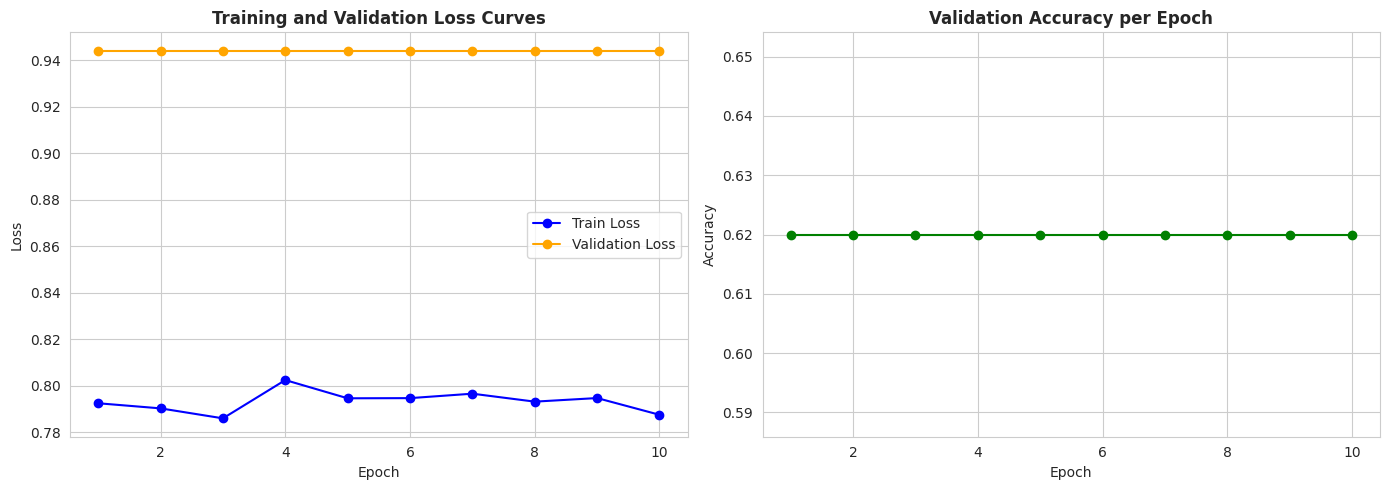

In [22]:
# Plot loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs+1), train_losses, 'o-', label='Train Loss', color='blue')
ax1.plot(range(1, epochs+1), val_losses, 'o-', label='Validation Loss', color='orange')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss Curves', fontweight='bold')
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, epochs+1), val_accuracies, 'o-', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy per Epoch', fontweight='bold')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Evaluate on Test Set

Test Loss: 1.0200
Test Accuracy: 0.5400

Classification Report:
              precision    recall  f1-score   support

         YES       0.57      0.82      0.67        56
          NO       0.42      0.24      0.30        34
       MAYBE       0.00      0.00      0.00        10

    accuracy                           0.54       100
   macro avg       0.33      0.35      0.32       100
weighted avg       0.46      0.54      0.48       100



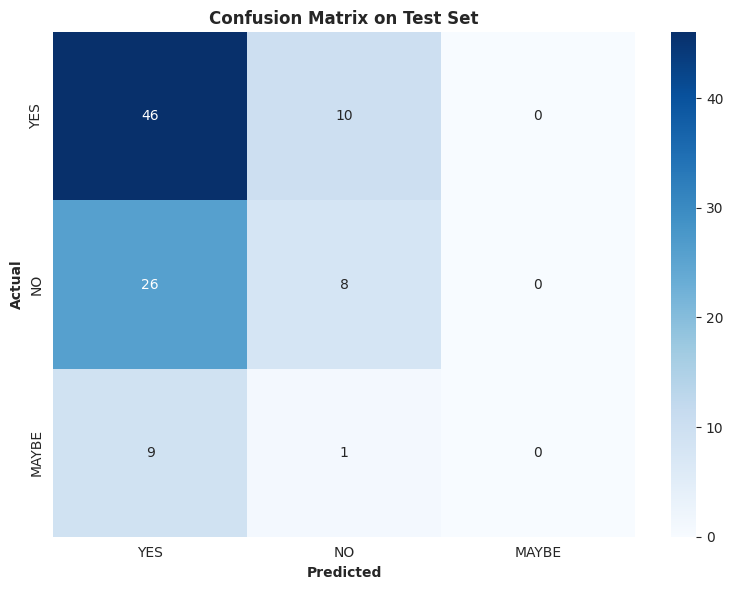

In [23]:
# Evaluate on test set
test_loss, test_acc, test_preds, test_actuals = evaluate(model, test_loader, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report
target_names = ['YES', 'NO', 'MAYBE']
print("\nClassification Report:")
print(classification_report(test_actuals, test_preds, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(test_actuals, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix on Test Set', fontweight='bold')
plt.tight_layout()
plt.show()

### Save the Fine‑tuned Model

In [24]:
# Save model locally
model_dir = "pubmedqa_model"
model.save_pretrained(model_dir)
tokenizer.save_pretrained(model_dir)
print(f"Model saved to local directory: {model_dir}")

# Optional: Save to Google Drive
drive_path = '/content/drive/MyDrive/Project7_PubMedQA_Model/'
os.makedirs(drive_path, exist_ok=True)
model.save_pretrained(drive_path)
tokenizer.save_pretrained(drive_path)
print(f"Model also saved to Google Drive: {drive_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to local directory: pubmedqa_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model also saved to Google Drive: /content/drive/MyDrive/Project7_PubMedQA_Model/


### Inference on a New Example

In [25]:
# Load the fine‑tuned model (if you closed the session)
# model = BertForSequenceClassification.from_pretrained(model_dir)
# tokenizer = BertTokenizer.from_pretrained(model_dir)
# model.to(device)

def predict(question, context):
    text = question + " " + context
    inputs = tokenizer(text, truncation=True, padding='max_length', max_length=max_length, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()
    return list(label_mapping.keys())[pred]

# Example inference using the new test_split
example_question = test_split["question"][0]
# The 'context' field in test_split[0] is a dictionary. We need the 'contexts' list within it.
example_context_dict = test_split["context"][0]
example_context_list_of_strings = example_context_dict["contexts"]
example_context_joined = " ".join(example_context_list_of_strings)

print(f"Question: {example_question}")
print(f"Context (first 300 chars): {example_context_joined[:300]}...")
print(f"Predicted Answer: {predict(example_question, example_context_joined)}")
print(f"True Answer: {test_split['final_decision'][0]}") # Adjusted to 'final_decision'


Question: Antiretroviral therapy related adverse effects: Can sub-Saharan Africa cope with the new "test and treat" policy of the World Health Organization?
Context (first 300 chars): Recent studies have shown that early antiretroviral therapy (ART) initiation results in significant HIV transmission reduction. This is the rationale behind the "test and treat" policy of the World Health Organization (WHO). Implementation of this policy will lead to an increased incidence of ART-re...
Predicted Answer: yes
True Answer: no


### Final Summary

In [26]:
print("\n" + "="*50)
print("PubMedQA Biomedical Question Answering - COMPLETED")
print("Author: Ibrahim")
print("="*50)
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(valid_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Model: BERT-base-uncased fine-tuned on PubMedQA")
print(f"Test Accuracy: {test_acc:.4f}")
print("\nSaved files:")
print(f" - Model and tokenizer in: {model_dir}")
print(" - Same saved to Google Drive (if mounted)")
print("\nAll visualizations displayed above. Model ready for inference.")


PubMedQA Biomedical Question Answering - COMPLETED
Author: Ibrahim
Training samples: 800
Validation samples: 100
Test samples: 100
Model: BERT-base-uncased fine-tuned on PubMedQA
Test Accuracy: 0.5400

Saved files:
 - Model and tokenizer in: pubmedqa_model
 - Same saved to Google Drive (if mounted)

All visualizations displayed above. Model ready for inference.
